In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml
from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/actxdes/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)



In [103]:
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

# deproj = 'cib_1p8_dBeta'
# true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy'

deproj = 'cib_1p7_dBeta'
true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'


# deproj = 'cib_1p8'
# true_y_file = 'ilc_SZ_deproj_cib_1.8_10.7_yy'

analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + f'/DESxACT/ACT_Cls/Cls_{true_y_file}_apod10arcmin_21Mar24.txt')
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = jnp.array([0.243, 0.262, 0.259, 0.301])
# analysis_dict['neff_arcmin2_SN_bins'] = jnp.array([1.476, 1.479, 1.484, 1.461])
analysis_dict['stats_for_cov'] = ['ky', 'kk']


halo_params_dict['rmax'] = 8
halo_params_dict['nr'] = 16

halo_params_dict['zmax_for_Cls'] = 1.6
halo_params_dict['zmax'] = 1.6
halo_params_dict['nz'] = 16

halo_params_dict['lg10_Mmin'] = 11.5
halo_params_dict['lg10_Mmax'] = 15.0
halo_params_dict['nM'] = 16

halo_params_dict['nk'] = 48


# sim_params_dict['cosmo']['sigma8'] = 0.59675
# sim_params_dict['cosmo']['Om0'] = 0.401

# sim_params_dict['cosmo']['sigma8'] = 0.68
# sim_params_dict['cosmo']['Om0'] = 0.3

sim_params_dict['cosmo']['sigma8'] = 0.72
sim_params_dict['cosmo']['Om0'] = 0.27
sim_params_dict['cosmo']['Ob0'] = 0.048
sim_params_dict['cosmo']['H0'] = 70.3

# sim_params_dict['theta_ej_0'] = 1.0
# sim_params_dict['nu_theta_ej_M'] = -0.2
# sim_params_dict['mu_beta'] = 0.2
# sim_params_dict['log10_Mc0'] = 14.0
# sim_params_dict['delta_rhogas'] = 6.0
# sim_params_dict['gamma_rhogas'] = 2.0

# sim_params_dict['theta_ej_0'] = 0.8
# sim_params_dict['theta_ej_0'] = 1.186
# sim_params_dict['nu_theta_ej_M'] = -0.16
# # sim_params_dict['theta_ej_0'] = 1.21
# sim_params_dict['theta_co_0'] = 0.115
# # sim_params_dict['nu_theta_ej_M'] = -0.1425
# sim_params_dict['nu_theta_ej_z'] = -0.2361
# sim_params_dict['mu_beta'] = 0.616
# sim_params_dict['log10_Mc0'] = 14.39
# sim_params_dict['delta_rhogas'] = 8.997
# sim_params_dict['gamma_rhogas'] = 3.94

sim_params_dict['cosmo']['sigma8'] = 0.7755
sim_params_dict['cosmo']['Om0'] = 0.307
sim_params_dict['cosmo']['Ob0'] = 0.036
sim_params_dict['cosmo']['H0'] = 68.6
sim_params_dict['theta_ej_0'] = 2.5
sim_params_dict['nu_theta_ej_M'] = -0.2
sim_params_dict['nu_theta_ej_z'] = 0.43
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0

sim_params_dict['theta_co_0'] = 0.075
sim_params_dict['nu_theta_co_z'] = 0.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['log10_Mstar0_theta_co'] = 15.0

sim_params_dict['mu_beta'] = 0.73
sim_params_dict['log10_Mc0'] = 13.0
sim_params_dict['delta_rhogas'] = 6.0
sim_params_dict['gamma_rhogas'] = 2.5

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.4
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4

sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2


analysis_dict['sigma_epsilon_SN_bins'] = jnp.array([0.268, 0.268, 0.268, 0.268])
analysis_dict['neff_arcmin2_SN_bins'] = jnp.array([1.795,1.5522,1.5966,1.099])

# other_params_dict.get('alpha_ky', 1.0)
# other_params_dict['alpha_ky'] = 0.7536
other_params_dict['alpha_ky'] = 0.80


In [104]:
# sim_params_dict['cosmo']['sigma8'] = 0.75
# sim_params_dict['cosmo']['Om0'] = 0.27
# sim_params_dict['theta_ej_0'] = 1.0
# sim_params_dict['nu_theta_ej_M'] = -0.2
# sim_params_dict['nu_theta_ej_z'] = 0.1
# sim_params_dict['theta_co_0'] = 0.025
# halo_params_dict['rmax'] = 8
# halo_params_dict['nr'] = 18

# halo_params_dict['zmax_for_Cls'] = 1.6
# halo_params_dict['zmax'] = 1.6
# halo_params_dict['nz'] = 18

# halo_params_dict['lg10_Mmin'] = 11.5
# halo_params_dict['lg10_Mmax'] = 15.5
# halo_params_dict['nM'] = 18

# halo_params_dict['nk'] = 48

# analysis_dict['num_points_trapz_int']= 48


In [105]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



In [ ]:
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)




Loaded up y-total file


In [7]:
deproj


'cib_1p7_dBeta'

In [8]:
df_cs = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
cov_xip_xim = df_cs['COVMAT'].data[:400,:400]
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
nbins = 4
ntheta_bin = 20
ldir = os.path.abspath(abs_path_data + '/DESxACT/measurements_shear_y/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')

xi_all = np.zeros(480)
theta_all = np.zeros(480)
bin1_all = np.zeros(480)
bin2_all = np.zeros(480)

ind_th_sel = np.where( (cov_test.fftcovtot_dict['ky_ky']['theta'] > 2.5) & (cov_test.fftcovtot_dict['ky_ky']['theta'] < 250.0))[0]
cov_gty_gty = np.zeros((ntheta_bin*nbins,ntheta_bin*nbins))


jstart = 0
for j1 in range(nbins):
    for j2 in range(nbins):
        cov_gty_gty[ntheta_bin*j1:ntheta_bin*(j1+1),ntheta_bin*j2:ntheta_bin*(j2+1)] = cov_test.fftcovtot_dict['gty_gty']['bin_' + str(j1+1) + '_0_' + str(j2+1) + '_0'][ind_th_sel,:][:,ind_th_sel]           
        if j1 == j2:
            df = pk.load(open(ldir + '/kg_act_deprojects_' + deproj + '_vnew_wbeam_pixell_zbin_' + str(j2) + '_njk_250_healpix4096_theta_2p5_250_v27Jan24.pk','rb'))                
            rkg = df['r_kg']
            covkg = df['cov_dy']
            xikg = df['xi_kg']
            # xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = DV.xi_result_dict['gty']['yt_1bin_%d_0'%(j1+1)]['tot']
            xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = xikg      
            theta_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = rkg     
            bin1_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.ones_like(rkg)*j1
            bin2_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.zeros_like(rkg)

jstart = 80
xi_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['VALUE']
theta_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['ANG']
bin1_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN1']
bin2_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN2']


jstart = 280
xi_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['VALUE']
theta_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['ANG']
bin1_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN1']
bin2_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN2']


cov_gty_xip_mat = np.zeros((80,200))
for jby in range(len(biny_vals)):
    by = biny_vals[jby]
    for jbk in range(len(bin1_vals)):
        b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
        val_here = cov_test.fftcovtot_dict['gty_kk']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
        cov_gty_xip_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here
        
cov_gty_xim_mat = np.zeros((80,200))
for jby in range(len(biny_vals)):
    by = biny_vals[jby]
    for jbk in range(len(bin1_vals)):
        b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
        val_here = cov_test.fftcovtot_dict['gty_kkm']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
        cov_gty_xim_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here


cov_total = np.zeros((480, 480))
# assemble the pieces:
cov_total[0:80, 0:80] = cov_gty_gty
cov_total[0:80, 80:280] = cov_gty_xip_mat
cov_total[0:80, 280:480] = cov_gty_xim_mat
cov_total[80:280, 0:80] = cov_gty_xip_mat.T
cov_total[280:480, 0:80] = cov_gty_xim_mat.T
cov_total[80:480, 80:480] = cov_xip_xim

print(np.sqrt(np.dot(xi_all[0:80], np.dot(np.linalg.inv(cov_gty_gty), xi_all[0:80]))))



18.899229116969014


In [85]:
# xi_all.shape
# df3 = pk.load(open('/mnt/ceph/users/spandey/GODMAX/data/DESxACT/measurements_shear_y/kg_act_deprojects_cib_1p7_dBeta_vnew_wbeam_pixell_zbin_3_njk_250_healpix4096_theta_2p5_250_v27Jan24.pk','rb'))
df3 = pk.load(open('/mnt/ceph/users/spandey/GODMAX/data/DESxACT/measurements_shear_y/kg_act_deprojects_cib_1p7_dBeta_vnew_wbeam_pixell_zbin_3_njk_250_healpix4096_theta_2p5_250_v27Jan24.pk','rb'))

# df3.keys()
df3['xi_kg']


array([9.29483413e-10, 1.31984404e-09, 1.37346650e-09, 1.27360140e-09,
       1.31712356e-09, 1.23038446e-09, 9.29068324e-10, 8.26225774e-10,
       7.56854632e-10, 8.29882064e-10, 5.26391126e-10, 4.26043909e-10,
       3.64327588e-10, 2.07323506e-10, 1.82317077e-10, 9.70144512e-11,
       1.03002157e-10, 3.12243289e-11, 4.17601066e-11, 3.52924692e-11])

In [18]:
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = profiles_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = profiles_test.M_array
Y_model_all = np.zeros(len(M_array))
Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = profiles_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)

    Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    Y_ss_all[jM] = Y_ss
    


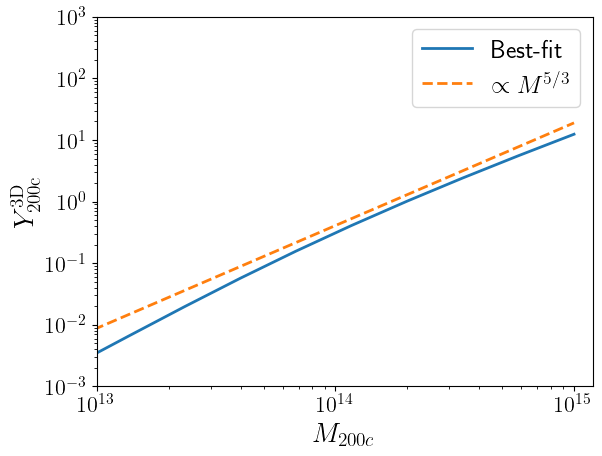

In [19]:
pl.figure()
pl.plot(M_array, Y_model_all, label='Best-fit', lw=2.0)
pl.plot(M_array, 1.9e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 1e3)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()


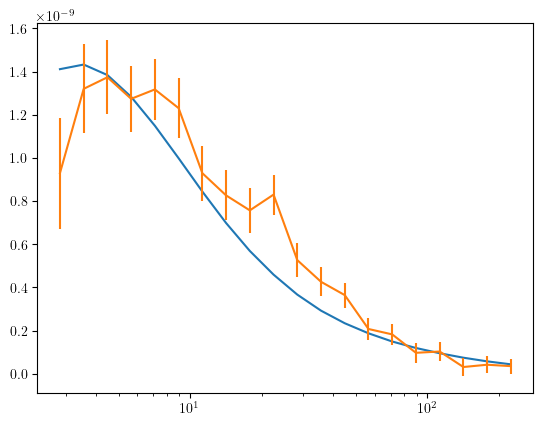

In [106]:
# xis_test.gty_out_mat.shape
bj = 3
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.gty_out_mat[:,bj])
pl.errorbar(analysis_dict['angles_data_array'], xi_all[20*bj:20*(bj+1)], yerr=sig_all[20*bj:20*(bj+1)])
# pl.yscale('log')
pl.xscale('log')
# xis_test.gty_out_mat.shape
# bj = 3
# indsel = np.where((bin1_all == bj) & (bin2_all == bj))[0]
# sig_all = np.sqrt(np.diag(cov_total))
# pl.figure()
# pl.plot(analysis_dict['angles_data_array'], xis_test.xip_out_mat[:,bj, bj])
# pl.errorbar(analysis_dict['angles_data_array'], xi_all[indsel][0:20], yerr=sig_all[indsel][0:20])
# pl.yscale('log')
# pl.xscale('log')



In [75]:
xi_all[60:80]

array([9.29483413e-10, 1.31984404e-09, 1.37346650e-09, 1.27360140e-09,
       1.31712356e-09, 1.23038446e-09, 9.29068324e-10, 8.26225774e-10,
       7.56854632e-10, 8.29882064e-10, 5.26391126e-10, 4.26043909e-10,
       3.64327588e-10, 2.07323506e-10, 1.82317077e-10, 9.70144512e-11,
       1.03002157e-10, 3.12243289e-11, 4.17601066e-11, 3.52924692e-11])

In [90]:
df2 = pk.load(open('/mnt/ceph/users/spandey/GODMAX/data/DESxACT/DV/DESxACT_gty_xip_xim_DV_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy.pk','rb'))
df2.keys()
# df2['xi_all'][60:80]


dict_keys(['theta_all', 'xi_all', 'cov_total', 'bin1_all', 'bin2_all'])

Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

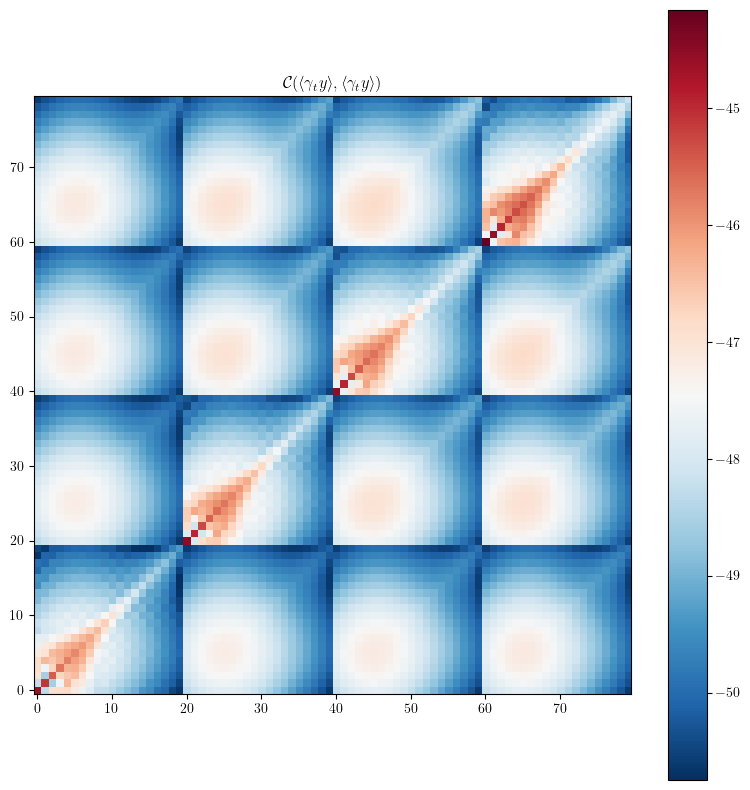

In [111]:
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

# corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')
corr = ax.imshow(np.log(np.abs(cov_total[0:80,0:80])), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

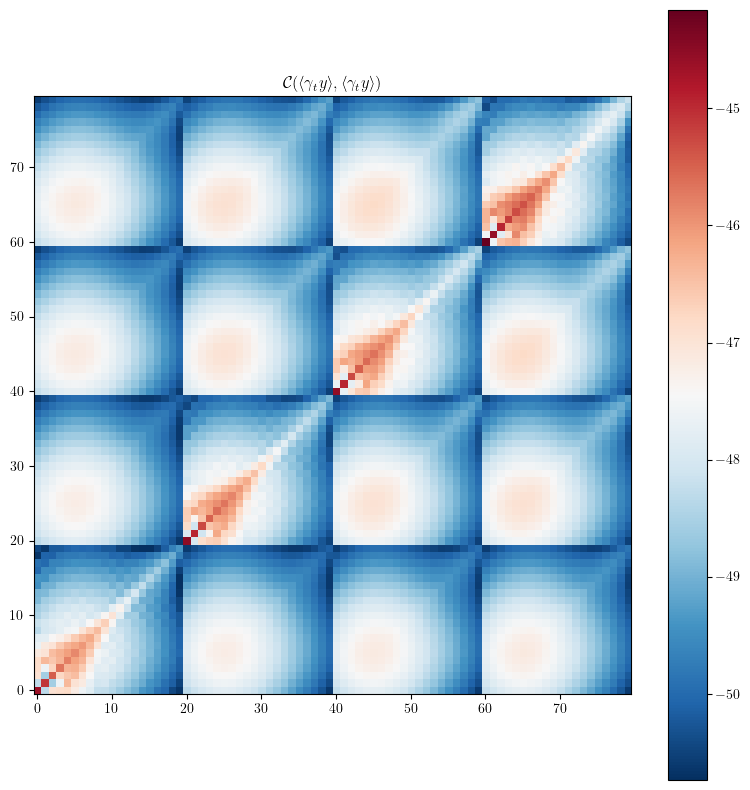

In [116]:
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

# corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')
corr = ax.imshow(np.log(np.abs(cov_total[0:80,0:80])), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



In [117]:
# np.amax(cov_total[0:80,0:80])
# cov_test.uyl_mat
np.diag(cov_test.covG_dict['ky_ky']['bin_4_0_4_0'])/np.diag(cov_test.covNG_dict['ky_ky']['bin_4_0_4_0'])


array([3.13141351e+02, 2.24789335e+02, 1.67551968e+02, 1.26168953e+02,
       9.88084410e+01, 8.23711030e+01, 7.14673351e+01, 6.38696441e+01,
       5.88893133e+01, 4.29789168e+01, 2.33965105e+01, 1.35466685e+01,
       8.84259146e+00, 7.22374662e+00, 6.67471385e+00, 6.83436863e+00,
       7.63735953e+00, 8.95038466e+00, 1.18002211e+01, 1.66328259e+01,
       2.18226114e+01, 2.59862381e+01, 2.21579408e+01, 1.68455192e+01,
       2.47955610e+01, 5.97878509e+01, 5.51540402e+02, 2.92299139e+03,
       1.96329962e+04, 1.38216682e+05, 2.34928393e+06, 1.20438056e+08,
       3.45705528e+10, 1.41285583e+14, 3.49585314e+19, 5.25657853e+27,
       2.10027074e+40])

In [108]:
# np.amax(cov_total[0:80,0:80])
# cov_test.uyl_mat
np.diag(cov_test.covG_dict['ky_ky']['bin_4_0_4_0'])/np.diag(cov_test.covNG_dict['ky_ky']['bin_4_0_4_0'])


array([3.26825282e+02, 2.33971081e+02, 1.72719951e+02, 1.30151083e+02,
       1.01796222e+02, 8.39713817e+01, 7.26716533e+01, 6.48297890e+01,
       5.97825165e+01, 4.37199627e+01, 2.40553016e+01, 1.38207896e+01,
       8.97781717e+00, 7.34284043e+00, 6.86792204e+00, 6.87905037e+00,
       7.62321376e+00, 9.00269575e+00, 1.18663530e+01, 1.64236172e+01,
       2.16701669e+01, 2.61216558e+01, 2.19667316e+01, 1.65784640e+01,
       2.44677309e+01, 5.94484464e+01, 5.44773062e+02, 2.90901815e+03,
       1.93722792e+04, 1.38898643e+05, 2.35565787e+06, 1.25884128e+08,
       3.67297674e+10, 1.75343788e+14, 5.79729639e+19, 1.90855224e+28,
       2.66264098e+41])

Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

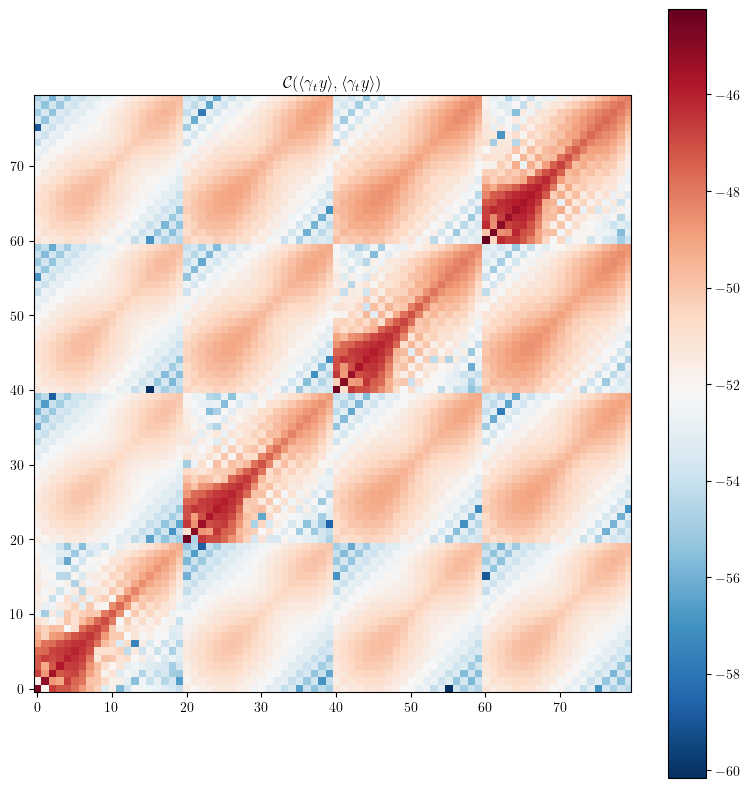

In [94]:
# pl.figure()
# pl.imshow(df2['cov_total'][0:80,0:80])
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

# corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')
corr = ax.imshow(np.log(np.abs((df2['cov_total'][0:80,0:80]))), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



(0.001, 3)

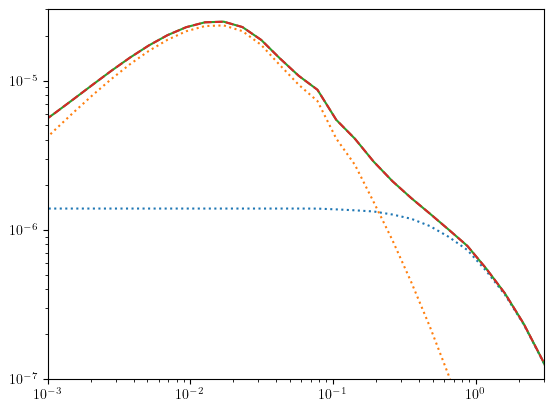

In [70]:
# Pkz_test.Pym_1h_kz_mat.shape
indz = 2
pl.figure()
pl.plot(Pkz_test.kPk_array, Pkz_test.Pym_1h_kz_mat[:,indz], ls=':')
pl.plot(Pkz_test.kPk_array, Pkz_test.Pym_2h_kz_mat[:,indz],ls=':')
pl.plot(Pkz_test.kPk_array, Pkz_test.Pym_tot_mat[:,indz], ls='-')
pl.plot(Pkz_test.kPk_array, (Pkz_test.Pym_1h_kz_mat[:,indz] + Pkz_test.Pym_2h_kz_mat[:,indz]), ls='--')
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pym_tot_mat[:,0]/(Pkz_test.Pym_1h_kz_mat[:,0] + Pkz_test.Pym_2h_kz_mat[:,0]))
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-7, 3e-5)
pl.xlim(1e-3, 3)


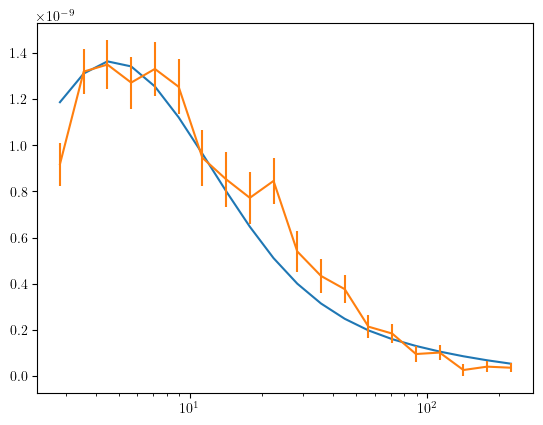

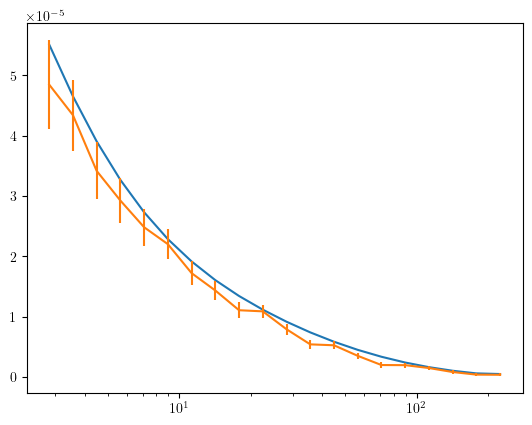

In [57]:
# xis_test.gty_out_mat.shape
bj = 3
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.gty_out_mat[:,bj])
pl.errorbar(analysis_dict['angles_data_array'], xi_all[20*bj:20*(bj+1)], yerr=sig_all[20*bj:20*(bj+1)])
# pl.yscale('log')
pl.xscale('log')
# xis_test.gty_out_mat.shape
bj = 3
indsel = np.where((bin1_all == bj) & (bin2_all == bj))[0]
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.xip_out_mat[:,bj, bj])
pl.errorbar(analysis_dict['angles_data_array'], xi_all[indsel][0:20], yerr=sig_all[indsel][0:20])
# pl.yscale('log')
pl.xscale('log')


In [9]:
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)




setting up realspace covariance
starting covariance of ky and ky
ky ky 1 0 1 0
ky ky 1 0 2 0
ky ky 1 0 3 0
ky ky 1 0 4 0
ky ky 2 0 1 0
ky ky 2 0 2 0
ky ky 2 0 3 0
ky ky 2 0 4 0
ky ky 3 0 1 0
ky ky 3 0 2 0
ky ky 3 0 3 0
ky ky 3 0 4 0
ky ky 4 0 1 0
ky ky 4 0 2 0
ky ky 4 0 3 0
ky ky 4 0 4 0
starting covariance of ky and kk
ky kk 1 0 1 1
ky kk 1 0 1 2
ky kk 1 0 1 3
ky kk 1 0 1 4
ky kk 1 0 2 1
ky kk 1 0 2 2
ky kk 1 0 2 3
ky kk 1 0 2 4
ky kk 1 0 3 1
ky kk 1 0 3 2
ky kk 1 0 3 3
ky kk 1 0 3 4
ky kk 1 0 4 1
ky kk 1 0 4 2
ky kk 1 0 4 3
ky kk 1 0 4 4
ky kk 2 0 1 1
ky kk 2 0 1 2
ky kk 2 0 1 3
ky kk 2 0 1 4
ky kk 2 0 2 1
ky kk 2 0 2 2
ky kk 2 0 2 3
ky kk 2 0 2 4
ky kk 2 0 3 1
ky kk 2 0 3 2
ky kk 2 0 3 3
ky kk 2 0 3 4
ky kk 2 0 4 1
ky kk 2 0 4 2
ky kk 2 0 4 3
ky kk 2 0 4 4
ky kk 3 0 1 1
ky kk 3 0 1 2
ky kk 3 0 1 3
ky kk 3 0 1 4
ky kk 3 0 2 1
ky kk 3 0 2 2
ky kk 3 0 2 3
ky kk 3 0 2 4
ky kk 3 0 3 1
ky kk 3 0 3 2
ky kk 3 0 3 3
ky kk 3 0 3 4
ky kk 3 0 4 1
ky kk 3 0 4 2
ky kk 3 0 4 3
ky kk 3 0 4 4
ky kk 

In [10]:
# deproj_all = ['cib_1p4','cib_1p6', 'cib_1p7', 'cib_1p8', 'cib_2p0', 'cib_1p4_dBeta','cib_1p6_dBeta','cib_1p7_dBeta','cib_1p8_dBeta','cib_2p0_dBeta']
deproj_all = ['cib_1p6_dBeta']

df_cs = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
cov_xip_xim = df_cs['COVMAT'].data[:400,:400]
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
nbins = 4
ntheta_bin = 20
ind_th_sel = np.where( (cov_test.fftcovtot_dict['ky_ky']['theta'] > 2.5) & (cov_test.fftcovtot_dict['ky_ky']['theta'] < 250.0))[0]
cov_gty_gty = np.zeros((ntheta_bin*nbins,ntheta_bin*nbins))
ldir = os.path.abspath(abs_path_data + '/DESxACT/measurements_shear_y/')

xi_all = np.zeros(480)
theta_all = np.zeros(480)
bin1_all = np.zeros(480)
bin2_all = np.zeros(480)

jstart = 0
for j1 in range(nbins):
    for j2 in range(nbins):
        cov_gty_gty[ntheta_bin*j1:ntheta_bin*(j1+1),ntheta_bin*j2:ntheta_bin*(j2+1)] = cov_test.fftcovtot_dict['gty_gty']['bin_' + str(j1+1) + '_0_' + str(j2+1) + '_0'][ind_th_sel,:][:,ind_th_sel]           
        if j1 == j2:
            df = pk.load(open(ldir + '/kg_act_deprojects_' + deproj_all[0] + '_vnew_wbeam_pixell_zbin_' + str(j2) + '_njk_250_healpix4096_theta_2p5_250_v27Jan24.pk','rb'))                
            rkg = df['r_kg']
            covkg = df['cov_dy']
            xikg = df['xi_kg']
            # xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = DV.xi_result_dict['gty']['yt_1bin_%d_0'%(j1+1)]['tot']
            xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = xikg      
            theta_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = rkg     
            bin1_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.ones_like(rkg)*j1
            bin2_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.zeros_like(rkg)

jstart = 80
xi_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['VALUE']
theta_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['ANG']
bin1_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN1']
bin2_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN2']


jstart = 280
xi_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['VALUE']
theta_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['ANG']
bin1_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN1']
bin2_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN2']


cov_gty_xip_mat = np.zeros((80,200))
for jby in range(len(biny_vals)):
    by = biny_vals[jby]
    for jbk in range(len(bin1_vals)):
        b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
        val_here = cov_test.fftcovtot_dict['gty_kk']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
        cov_gty_xip_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here
        
cov_gty_xim_mat = np.zeros((80,200))
for jby in range(len(biny_vals)):
    by = biny_vals[jby]
    for jbk in range(len(bin1_vals)):
        b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
        val_here = cov_test.fftcovtot_dict['gty_kkm']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
        cov_gty_xim_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here


cov_total = np.zeros((480, 480))
# assemble the pieces:
cov_total[0:80, 0:80] = cov_gty_gty
cov_total[0:80, 80:280] = cov_gty_xip_mat
cov_total[0:80, 280:480] = cov_gty_xim_mat
cov_total[80:280, 0:80] = cov_gty_xip_mat.T
cov_total[280:480, 0:80] = cov_gty_xim_mat.T
cov_total[80:480, 80:480] = cov_xip_xim




Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

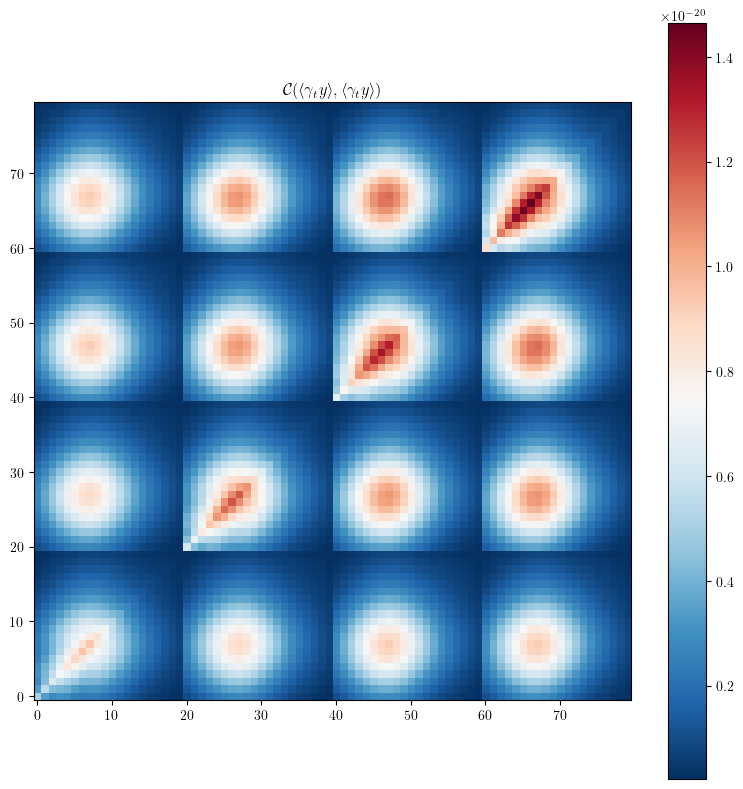

In [11]:
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

# corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')
corr = ax.imshow((((cov_total)[0:80,0:80])), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



(1e-12, 2e-09)

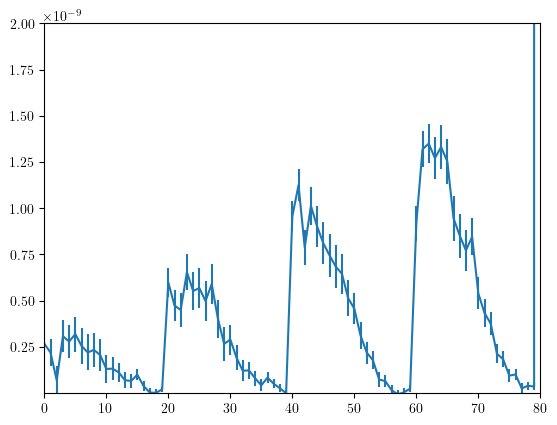

In [12]:
pl.figure()
pl.errorbar(np.arange(480), xi_all, yerr = np.sqrt(np.diag(cov_total)))
# pl.yscale('log')
pl.xlim(0, 80)
pl.ylim(1e-12, 2e-9)


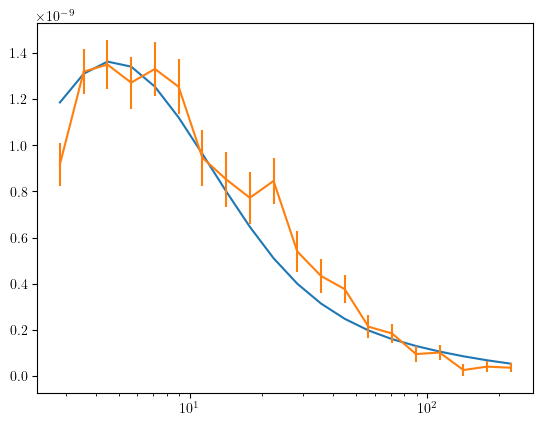

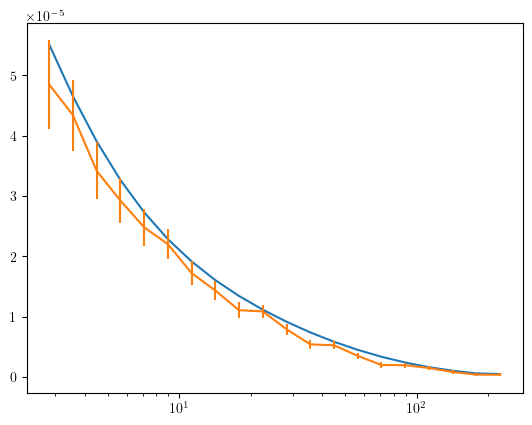

In [13]:
# xis_test.gty_out_mat.shape
bj = 3
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.gty_out_mat[:,bj])
pl.errorbar(analysis_dict['angles_data_array'], xi_all[20*bj:20*(bj+1)], yerr=sig_all[20*bj:20*(bj+1)])
# pl.yscale('log')
pl.xscale('log')
# xis_test.gty_out_mat.shape
bj = 3
indsel = np.where((bin1_all == bj) & (bin2_all == bj))[0]
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.xip_out_mat[:,bj, bj])
pl.errorbar(analysis_dict['angles_data_array'], xi_all[indsel][0:20], yerr=sig_all[indsel][0:20])
# pl.yscale('log')
pl.xscale('log')


In [107]:
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# probe = 'xip_xim' 
# probe = 'gty'
probe = 'all'



if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

P_total = jnp.linalg.inv(cov_total)



In [15]:
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )


In [16]:
df_cs = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])

# index_gty = {}
index_gty = []
for js in range(80):
    # index_gty[js] = [js%20 ,js//20]
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
# index_xip = {}
index_xip = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xip[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]
    index_xip.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xip = jnp.array(index_xip)
# index_xim = {}
index_xim = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xim[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]   
    index_xim.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xim = jnp.array(index_xim)

In [17]:
xis_test.gty_out_mat.shape



(20, 4)

In [18]:
prior_min_all_dict = {}
prior_max_all_dict = {}
prior_min_all_dict['Om0'] = 0.1
prior_max_all_dict['Om0'] = 0.5
prior_min_all_dict['Ob0'] = 0.03
prior_max_all_dict['Ob0'] = 0.07
prior_min_all_dict['h'] = 0.5
prior_max_all_dict['h'] = 0.9
prior_min_all_dict['ns'] = 0.8
prior_max_all_dict['ns'] = 1.2
prior_min_all_dict['sigma8'] = 0.6
prior_max_all_dict['sigma8'] = 1.0

prior_min_all_dict['theta_ej_0'] = 1.0
prior_max_all_dict['theta_ej_0'] = 5.0
prior_min_all_dict['log10_Mc0'] = 13.0
prior_max_all_dict['log10_Mc0'] = 15.0
prior_min_all_dict['nu_theta_ej_M'] = -1.0
prior_max_all_dict['nu_theta_ej_M'] = 0.0
prior_min_all_dict['nu_theta_ej_z'] = -1.0
prior_max_all_dict['nu_theta_ej_z'] = 1.0
prior_min_all_dict['alpha_nt'] = 0.0
prior_max_all_dict['alpha_nt'] = 0.4
prior_min_all_dict['mu_beta'] = 0.1
prior_max_all_dict['mu_beta'] = 1.0



prior_min_all_dict['A_IA'] = -3.0
prior_max_all_dict['A_IA'] = 3.0
prior_min_all_dict['eta_IA'] = -2.0
prior_max_all_dict['eta_IA'] = 2.0

prior_mu_all_dict = {}
prior_sig_all_dict = {}
prior_mu_all_dict['Delta_z_bias_bin1'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin1'] = 1.8e-2
prior_mu_all_dict['Delta_z_bias_bin2'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin2'] = 1.5e-2
prior_mu_all_dict['Delta_z_bias_bin3'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin3'] = 1.1e-2
prior_mu_all_dict['Delta_z_bias_bin4'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin4'] = 1.7e-2

prior_mu_all_dict['mult_shear_bias_bin1'] = -6e-3
prior_sig_all_dict['mult_shear_bias_bin1'] = 9e-3
prior_mu_all_dict['mult_shear_bias_bin2'] = -2e-2
prior_sig_all_dict['mult_shear_bias_bin2'] = 8e-3
prior_mu_all_dict['mult_shear_bias_bin3'] = -2.4e-2
prior_sig_all_dict['mult_shear_bias_bin3'] = 8e-3
prior_mu_all_dict['mult_shear_bias_bin4'] = -3.7e-2
prior_sig_all_dict['mult_shear_bias_bin4'] = 8e-3

prior_delta_z_mu_all = jnp.array([prior_mu_all_dict['Delta_z_bias_bin1'], prior_mu_all_dict['Delta_z_bias_bin2'], prior_mu_all_dict['Delta_z_bias_bin3'], prior_mu_all_dict['Delta_z_bias_bin4']])
prior_delta_z_sig_all = jnp.array([prior_sig_all_dict['Delta_z_bias_bin1'], prior_sig_all_dict['Delta_z_bias_bin2'], prior_sig_all_dict['Delta_z_bias_bin3'], prior_sig_all_dict['Delta_z_bias_bin4']])

prior_mult_shear_mu_all = jnp.array([prior_mu_all_dict['mult_shear_bias_bin1'], prior_mu_all_dict['mult_shear_bias_bin2'], prior_mu_all_dict['mult_shear_bias_bin3'], prior_mu_all_dict['mult_shear_bias_bin4']])
prior_mult_shear_sig_all = jnp.array([prior_sig_all_dict['mult_shear_bias_bin1'], prior_sig_all_dict['mult_shear_bias_bin2'], prior_sig_all_dict['mult_shear_bias_bin3'], prior_sig_all_dict['mult_shear_bias_bin4']])




In [19]:
cosmo_params_vary_names = ['Om0', 'sigma8', 'Ob0', 'h', 'ns']
sims_params_vary_names = ['mu_beta', 'nu_theta_ej_M', 'nu_theta_ej_z']
# sims_params_vary_names = []
# cosmo_params_vary_names = []
IA_params_vary_names = ['A_IA', 'eta_IA']
# IA_params_vary_names = ['eta_IA']
# IA_params_vary_names = []

mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4'] 
Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4']

custom_init_values_dict = {'Om0': 0.27, 'sigma8': 0.75, 'Ob0': 0.045, 'h': 0.7, 'ns': 0.96, 'A_IA': 0.1, 'eta_IA': 0.01, 'mu_beta': 0.6, 'nu_theta_ej_M': -0.15, 'nu_theta_ej_z': 0.1, 'Delta_z_bias_array': jnp.zeros(4), 'mult_shear_bias_array': jnp.zeros(4)}




In [20]:
from godmax.get_Xis import get_xi
import numpyro
import copy

def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    if len(cosmo_params_vary_names) > 0:
        for jp in range(len(cosmo_params_vary_names)):
            if cosmo_params_vary_names[jp] == 'h':
                fac = 100.
                cosmo_name = 'H0'
            else:
                fac = 1.
                cosmo_name = cosmo_params_vary_names[jp]
            prior_min_jp = prior_min_all_dict[cosmo_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[cosmo_params_vary_names[jp]]
            sim_params_dict_vary['cosmo'][cosmo_name] = fac * Uniform(cosmo_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(sims_params_vary_names) > 0:
        for jp in range(len(sims_params_vary_names)):
            prior_min_jp = prior_min_all_dict[sims_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[sims_params_vary_names[jp]]
            sim_params_dict_vary[sims_params_vary_names[jp]] = Uniform(sims_params_vary_names[jp], prior_min_jp, prior_max_jp)
    
    if len(IA_params_vary_names) > 0:
        for jp in range(len(IA_params_vary_names)):
            prior_min_jp = prior_min_all_dict[IA_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[IA_params_vary_names[jp]]
            other_params_dict_vary[IA_params_vary_names[jp]] = Uniform(IA_params_vary_names[jp], prior_min_jp, prior_max_jp)
        
    if len(prior_delta_z_mu_all) > 0:
        Delta_z_bias_array = numpyro.sample('Delta_z_bias_array', dist.Normal(prior_delta_z_mu_all, prior_delta_z_sig_all)) 
        other_params_dict_vary['Delta_z_bias_array'] = Delta_z_bias_array
    
    if len(prior_mult_shear_mu_all) > 0:
        mult_shear_bias_array = numpyro.sample('mult_shear_bias_array', dist.Normal(prior_mult_shear_mu_all, prior_mult_shear_sig_all))
        other_params_dict_vary['mult_shear_bias_array'] = mult_shear_bias_array
        
    get_corrfunc_BCMP_test = get_xi(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    def get_gty_from_index(index):
        index_val = index_gty[index]
        return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

    def get_xip_from_index(index):
        index_val = index_xip[index]
        return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

    def get_xim_from_index(index):
        index_val = index_xim[index]
        return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

    gty_val = vmap(get_gty_from_index)(np.arange(80))
    xip_val = vmap(get_xip_from_index)(np.arange(200))
    xim_val = vmap(get_xim_from_index)(np.arange(200))

    if probe == 'xip_xim':
        mu = jnp.concatenate([xip_val, xim_val])
    elif probe == 'gty':
        mu = gty_val
    else:
        mu = jnp.concatenate([gty_val, xip_val, xim_val])
    # print(mu.shape, P_total.shape, cov_total.shape)
    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                        precision_matrix=P_total,
                                                        covariance_matrix=cov_total))




In [21]:
import numpyro
numpyro.enable_x64()
numpyro.set_platform("gpu")
# numpyro.set_host_device_count(4)
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations
observed_model = condition(model, {'cl': data_vec})



In [22]:
import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)



In [29]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=5e-1, 
                            # init_strategy=numpyro.infer.init_to_sample,
                            init_strategy=numpyro.infer.init_to_value(values=custom_init_values_dict),                            
                            dense_mass=True,
                            max_tree_depth=4,
                            adapt_mass_matrix=True, 
                            adapt_step_size=True,
                            forward_mode_differentiation=False)




In [30]:
mcmc = numpyro.infer.MCMC(nuts_kernel, 
                          num_warmup=100, 
                          num_samples=100,
                          num_chains=12,
                          chain_method='vectorized',
                        #   chain_method='sequential',                          
                          progress_bar=True,
                          jit_model_args=True)



In [31]:
import jax

# mcmc.run(jax.random.PRNGKey(42), collect_diagnostics=True)
mcmc.run(jax.random.PRNGKey(42))
diagnostics = mcmc.get_extra_fields()


sample: 100%|██████████| 200/200 [10:04<00:00,  3.02s/it]


In [35]:
# diagnostics['diverging']
mcmc.print_summary()



                                         mean       std    median      5.0%     95.0%     n_eff     r_hat
                          A_IA_base      0.24      0.29      0.26     -0.27      0.64     15.04      1.45
   Delta_z_bias_array_decentered[0]      0.29      0.99      0.45     -1.25      1.84     13.54      1.70
   Delta_z_bias_array_decentered[1]     -0.34      0.74     -0.41     -1.37      0.90     12.16      1.66
   Delta_z_bias_array_decentered[2]      0.05      0.68      0.06     -1.11      1.09     34.35      1.25
   Delta_z_bias_array_decentered[3]      0.39      0.87      0.41     -1.18      1.62     10.66      1.69
                           Ob0_base     -2.00      1.01     -2.33     -2.99     -0.85      6.88      3.34
                           Om0_base     -0.72      0.25     -0.75     -1.11     -0.26     13.66      1.49
                        eta_IA_base      0.74      1.63      1.07     -1.54      3.00      9.22      2.01
                             h_base     -2.17

In [ ]:
tree_depths = diagnostics["tree_depth"]
print("Maximum tree depth reached:", (tree_depths == mcmc.sampler.kernel.max_tree_depth).sum())
pl.figure()
pl.hist(diagnostics["tree_depth"], bins=range(mcmc.sampler.kernel.max_tree_depth + 1))
pl.xlabel("Tree Depth")
pl.ylabel("Frequency")
pl.title("Tree Depth Distribution")


In [36]:
df = mcmc.get_samples()




In [37]:
df['Delta_z_bias_array']


Array([[ 0.01378547, -0.00018111, -0.00973951,  0.02089082],
       [ 0.01007954, -0.01043826, -0.01147288,  0.01792043],
       [ 0.01418574, -0.00103141, -0.01358603,  0.01282738],
       ...,
       [ 0.00814726,  0.00374124,  0.01570264,  0.02174469],
       [ 0.02701546,  0.00727485,  0.02144758,  0.03748818],
       [ 0.027184  ,  0.00645882,  0.02122931,  0.03726288]],      dtype=float64)

In [38]:
# df.keys()
# df['A_IA'].shape


(1200,)
(1200,)
(1200,)
(1200,)
(1200,)
(1200,)
(1200,)
(1200,)
(1140, 19)
Removed no burn in
2.248101901989593 7.919328712087707


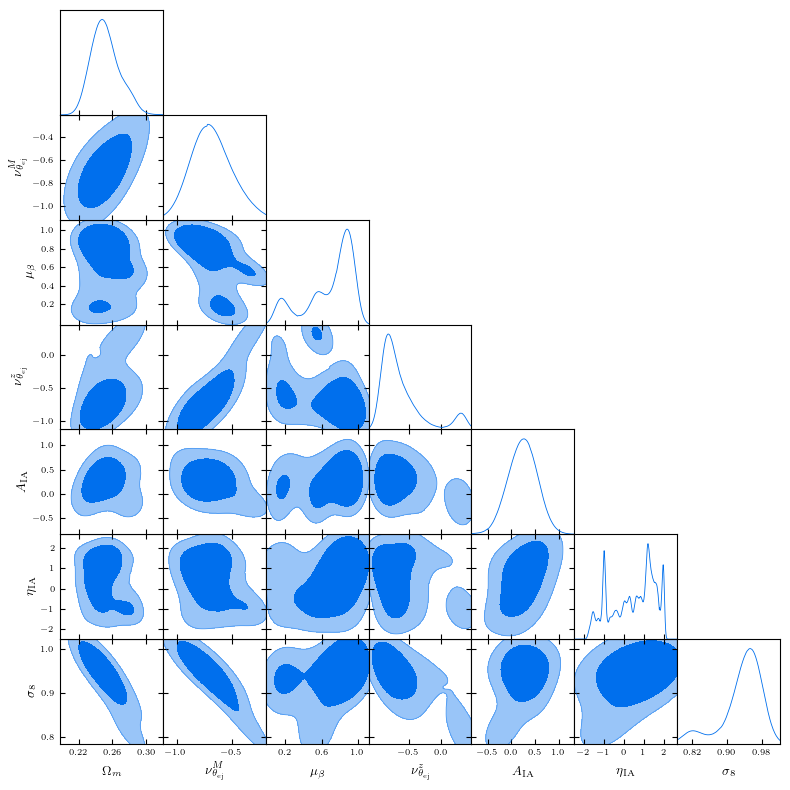

In [39]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
nchains = 12
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# # ind_del = np.array([4, 10])
# # ind_del = np.array([3])
# # ind_del = np.array([1,2,4,7])
# # ind_del = np.array([0,7,8,9,10])
# ind_del = [0]
# # ind_del = [3,5,8]
# # ind_del = [0,3,4,5,6,7,8,9,10,11]
# if len(ind_del) > 0:
#     samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
    # samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape)

# saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
# savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

from numpyro.diagnostics import gelman_rubin, effective_sample_size
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
ess = effective_sample_size(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
print(gr, ess)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
# params = ['Om0', 'gamma_rhogas', 'nu_theta_ej_M','nu_theta_ej_z','nu_theta_co_z', 'A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
# save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'test_vary_thetaej_mubeta_all_npf_response_response.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()



In [23]:
from numpyro.contrib.nested_sampling import NestedSampler


In [35]:
ns = NestedSampler(observed_model_reparam, constructor_kwargs={'max_samples':1000, 'num_live_points':50, 'c':50, 'verbose':True})




In [36]:
ns.run(jax.random.PRNGKey(42))



INFO:jaxns:Number of parallel Markov-chains set to: 50


-------
Num samples: 100
Num likelihood evals: 417
Efficiency: 0.11990407673860912
log(L) contour: 6205.327978208784
log(Z) est.: 6556.901958237376 +- 0.8324236243562017
-------
Num samples: 150
Num likelihood evals: 1377
Efficiency: 0.03631082062454612
log(L) contour: 6444.557130721991
log(Z) est.: 6616.084705215103 +- 0.8439094965985053
-------
Num samples: 200
Num likelihood evals: 3061
Efficiency: 0.01633453119895459
log(L) contour: 6518.2535991352715
log(Z) est.: 6620.931138551294 +- 0.8457718464622278
-------
Num samples: 250
Num likelihood evals: 5161
Efficiency: 0.00968804495252858
log(L) contour: 6562.733673093404
log(Z) est.: 6619.961649673986 +- 0.8462182631558831
-------
Num samples: 300
Num likelihood evals: 7807
Efficiency: 0.006404508774177021
log(L) contour: 6593.196628056206
log(Z) est.: 6630.495396974513 +- 0.8774100421822688
-------
Num samples: 350
Num likelihood evals: 11467
Efficiency: 0.004360338362256911
log(L) contour: 6610.817040979862
log(Z) est.: 6632.631390

In [37]:
ns.print_summary()




--------
Termination Conditions:
Reached max samples
--------
likelihood evals: 82562
samples: 950
phantom samples: 0
likelihood evals / sample: 86.9
phantom fraction (%): 0.0%
--------
logZ=6639.07 +- 0.53
H=-14.42
ESS=62
--------
A_IA: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
A_IA: 0.25 +- 0.21 | 0.02 / 0.26 / 0.48 | 0.21 | 0.21
--------
A_IA_base: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
A_IA_base: 0.25 +- 0.21 | 0.02 / 0.26 / 0.48 | 0.21 | 0.21
--------
Delta_z_bias_array[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
Delta_z_bias_array[0]: 0.007 +- 0.016 | -0.016 / 0.012 / 0.025 | 0.018 | 0.018
Delta_z_bias_array[1]: -0.009 +- 0.011 | -0.024 / -0.007 / 0.003 | -0.003 | -0.003
Delta_z_bias_array[2]: 0.0006 +- 0.0092 | -0.0135 / 0.003 / 0.0118 | 0.0124 | 0.0124
Delta_z_bias_array[3]: 0.011 +- 0.012 | -0.003 / 0.008 / 0.026 | 0.003 | 0.003
--------
Delta_z_bias_array_decentered[#]: mean +- std.dev. | 10

In [38]:
ns.diagnostics()



/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jaxns/plotting.py:47: UserWarning: Found samples with zero likelihood evaluations.
  warnings.warn("Found samples with zero likelihood evaluations.")
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jaxns/plotting.py:51: RuntimeWarning: divide by zero encountered in divide
  1. / num_likelihood_evaluations_per_sample


In [ ]:
# ns.print_summary()




In [39]:
# samples obtained from nested sampler are weighted, so
# we need to provide random key to resample from those weighted samples
# ns_samples = ns.get_samples(jax.random.PRNGKey(1), num_samples=100)
df = ns.get_samples(jax.random.PRNGKey(1), num_samples=4000)



In [31]:
# ns_samples.keys()


(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(4000,)
(3800, 19)
Removed no burn in


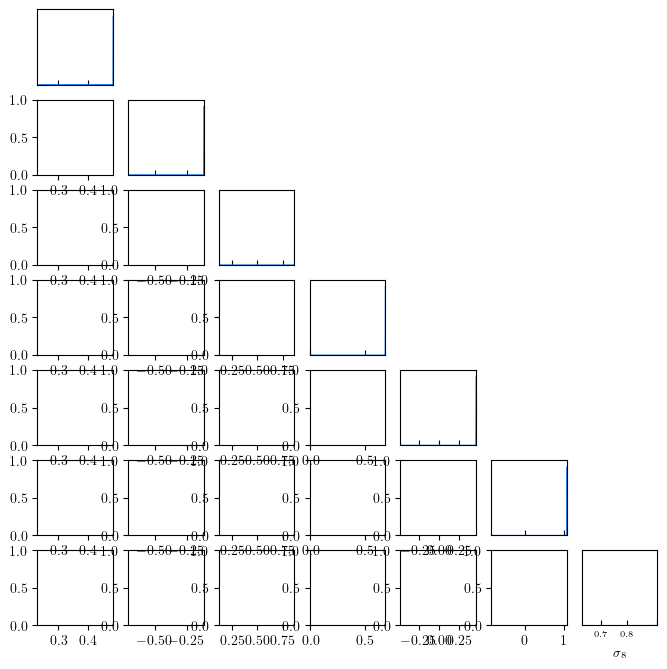

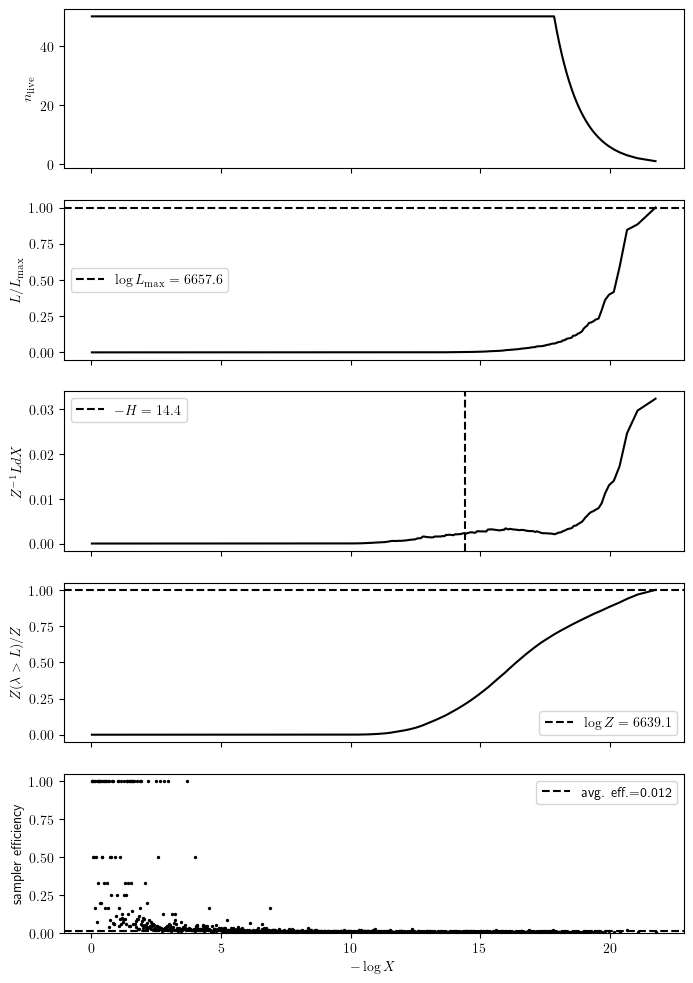

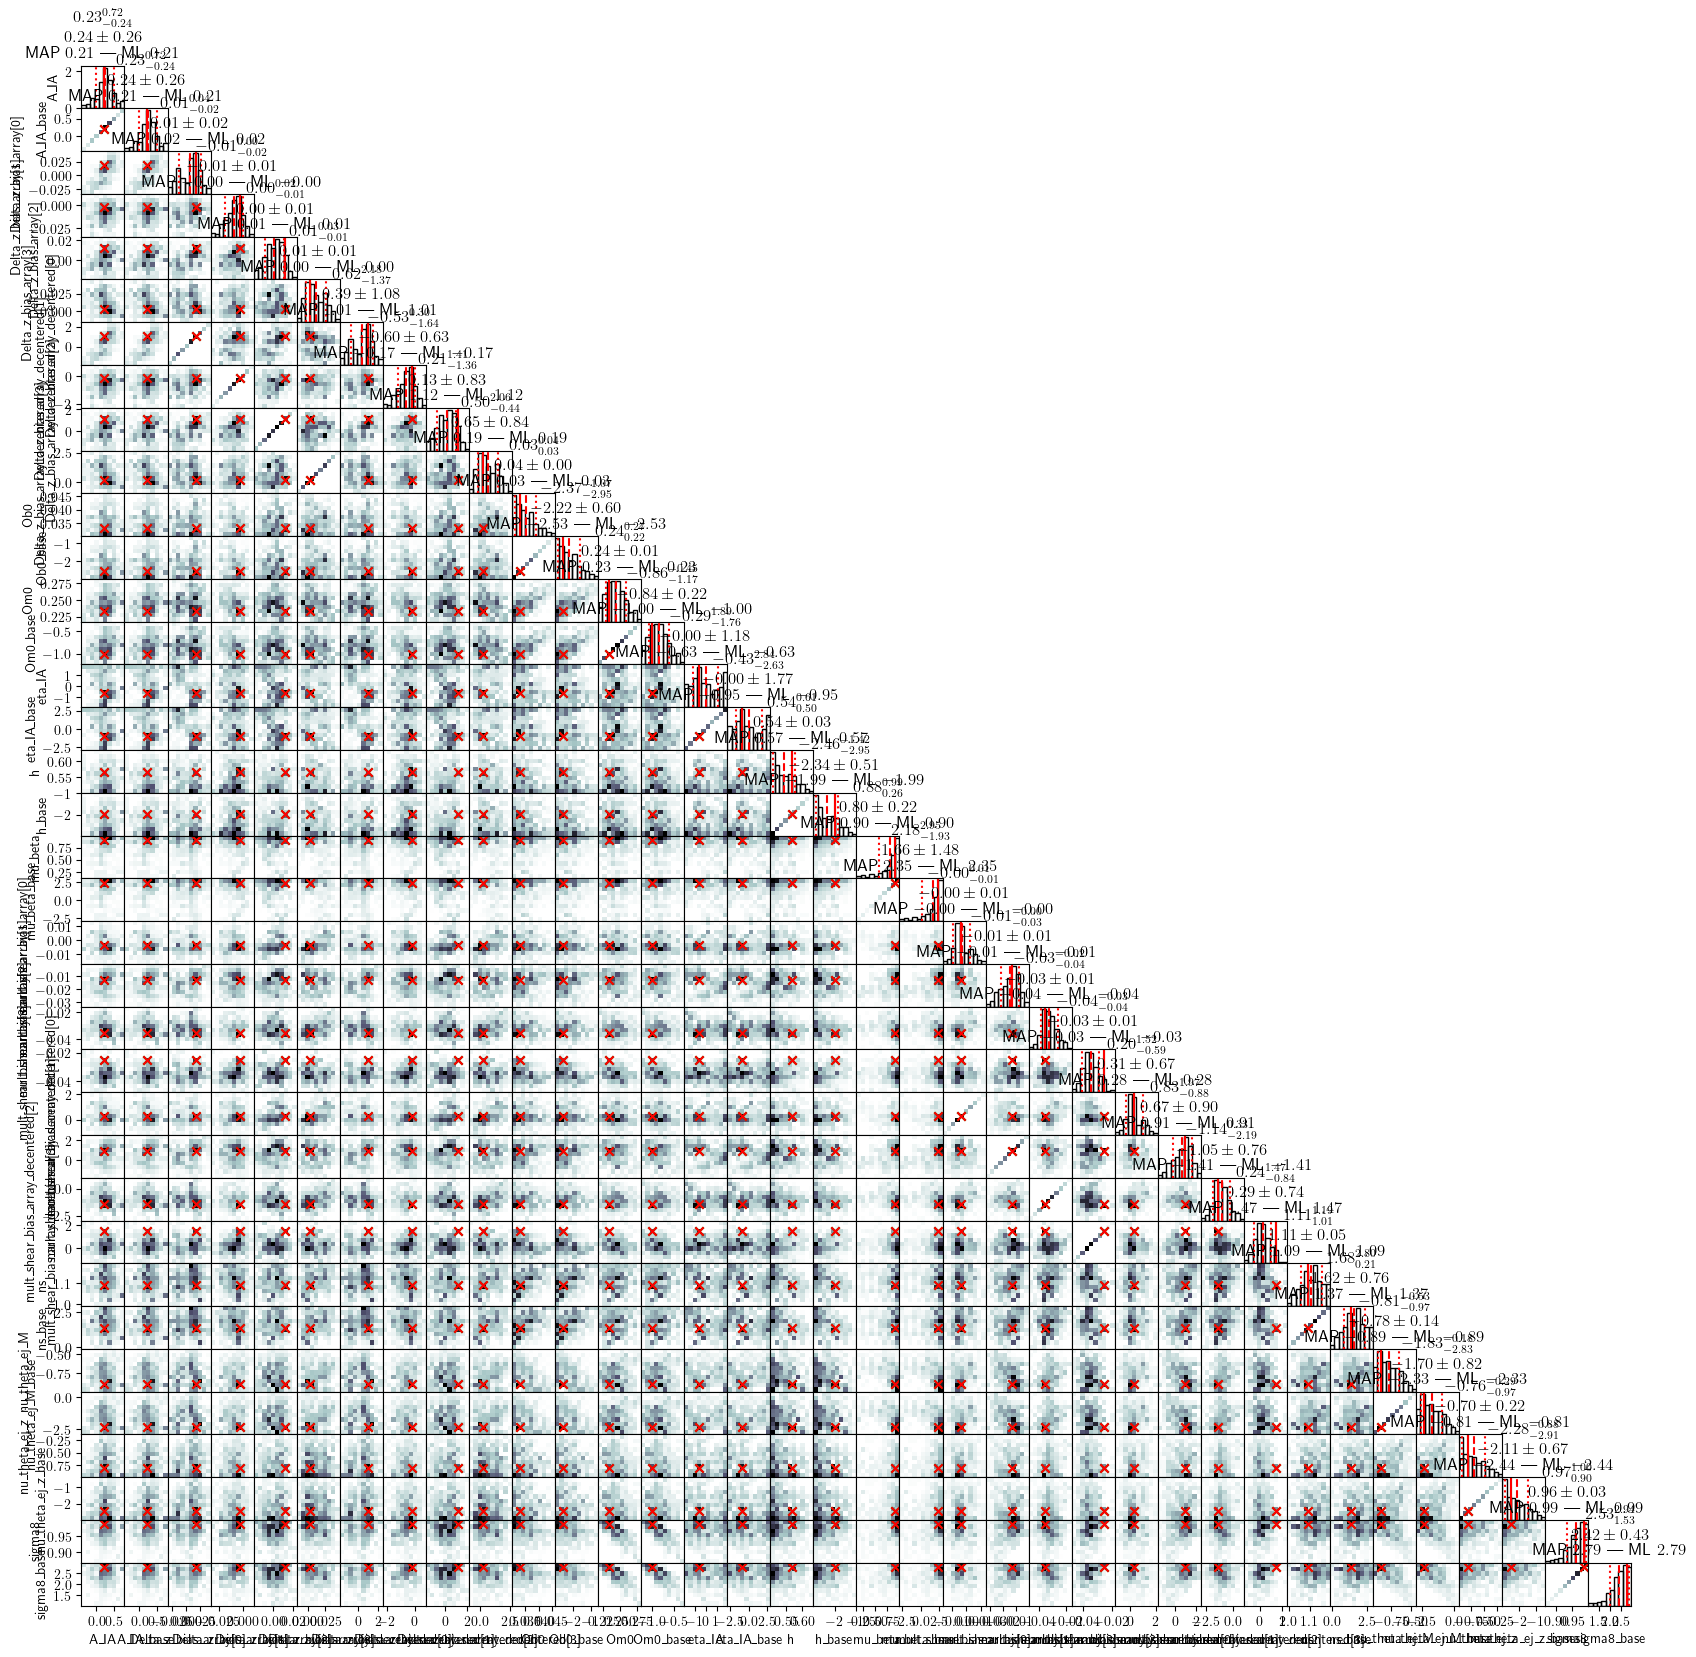

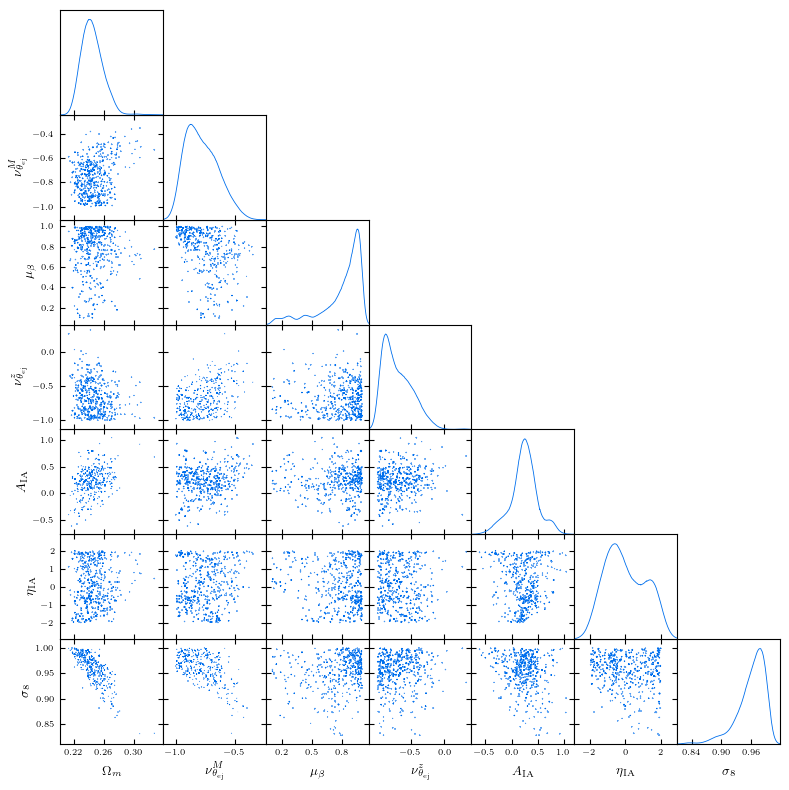

In [40]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
nchains = 1
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# # ind_del = np.array([4, 10])
# # ind_del = np.array([3])
# # ind_del = np.array([1,2,4,7])
# # ind_del = np.array([0,7,8,9,10])
# ind_del = [0]
# # ind_del = [3,5,8]
# # ind_del = [0,3,4,5,6,7,8,9,10,11]
# if len(ind_del) > 0:
#     samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
    # samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape)

# saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
# savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

# from numpyro.diagnostics import gelman_rubin, effective_sample_size
# ind_gr = ind_sigma8
# gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
# ess = effective_sample_size(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
# print(gr, ess)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
# params = ['Om0', 'gamma_rhogas', 'nu_theta_ej_M','nu_theta_ej_z','nu_theta_co_z', 'A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
# save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'test_vary_thetaej_mubeta_all_npf_response_response.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()



In [60]:
get_corrfunc_BCMP_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

def get_gty_from_index(index):
    index_val = index_gty[index]
    return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_val = vmap(get_gty_from_index)(np.arange(80))
xip_val = vmap(get_xip_from_index)(np.arange(200))
xim_val = vmap(get_xim_from_index)(np.arange(200))

if probe == 'xip_xim':
    mu = jnp.concatenate([xip_val, xim_val])
elif probe == 'gty':
    mu = gty_val
else:
    mu = jnp.concatenate([gty_val, xip_val, xim_val])

    

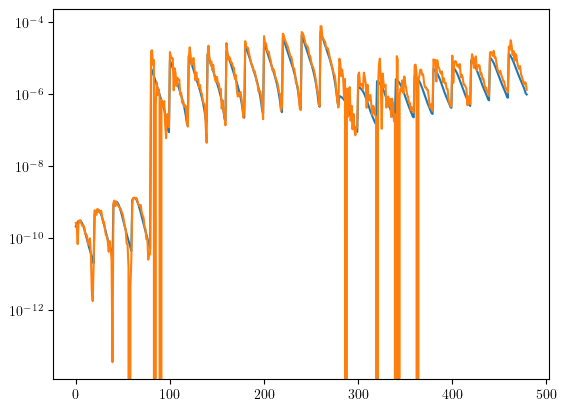

In [61]:
# samps = np.array(samps).T
pl.figure()
pl.plot(mu)
pl.plot(data_vec)
pl.yscale('log')

